## **Atelier Seaborn**

In [1]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\HP 450 G8\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
# Import des bibliothèques nécessaires pour tout le notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thème Seaborn appliqué à l'ensemble du notebook
sns.set_theme(style="whitegrid")

print("Pandas version    :", pd.__version__)
print("NumPy version     :", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version   :", sns.__version__)

Pandas version    : 3.0.3
NumPy version     : 2.5.0
Matplotlib version: 3.11.1
Seaborn version   : 0.13.2


### Import et vérification du jeu de données

In [4]:
# Import du CSV fourni dans le DataFrame df
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [5]:
# Vérification du contenu du DataFrame
print("Dimensions :", df.shape)
df.info()

Dimensions : (605, 9)
<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 63.0 KB


In [6]:
# Statistiques descriptives des colonnes numériques
df.describe()

,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


Le jeu de données contient 605 mesures réparties sur 4 bâtiments (B001 à B004), avec quelques valeurs manquantes (colonnes `temperature`, `humidite`, `pression`, `consommation`, `etat`) déjà identifiées lors de l'atelier Pandas. Ces valeurs manquantes sont ignorées automatiquement par Seaborn dans les graphiques qui suivent, ce qui n'empêche pas de mener l'analyse exploratoire.

## Partie 1 – Distribution d'une variable avec `histplot()`

1) Distribution des températures

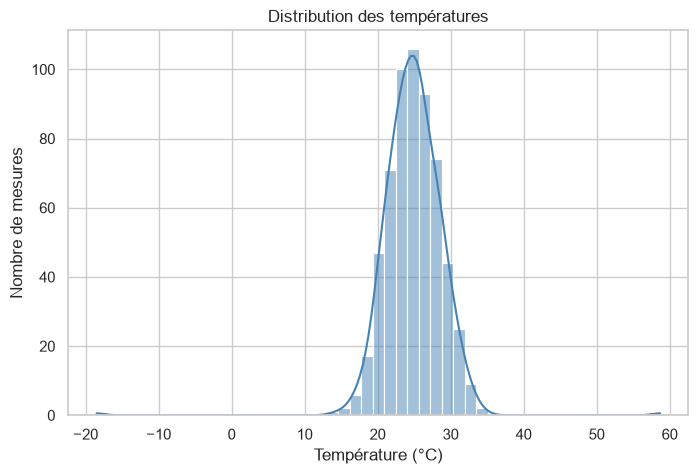

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="temperature", kde=True, color="steelblue")
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

In [8]:
print("Moyenne   :", round(df["temperature"].mean(), 2))
print("Médiane   :", round(df["temperature"].median(), 2))
print("Ecart-type:", round(df["temperature"].std(), 2))
print("Min / Max :", df["temperature"].min(), "/", df["temperature"].max())

Moyenne   : 24.88
Médiane   : 24.86
Ecart-type: 4.06
Min / Max : -18.5 / 58.7


2) **Concentration** : les températures sont concentrées autour de 25°C (moyenne 24,9°C, médiane 24,9°C), ce qui correspond à une température ambiante intérieure classique pour des bâtiments équipés de capteurs.

3) **Symétrie** : la distribution est globalement symétrique autour de sa valeur centrale — le corps de l'histogramme suit une forme proche d'une cloche. Elle est cependant légèrement étalée vers les deux extrémités à cause des valeurs aberrantes.

4) **Valeurs extrêmes** : oui, on observe des valeurs extrêmes très éloignées du reste de la distribution (température minimale de -18,5°C et maximale de 58,7°C), physiquement peu plausibles pour des capteurs intérieurs — probablement des erreurs de capteur ou de transmission.

5) Modification du nombre de classes (bins)

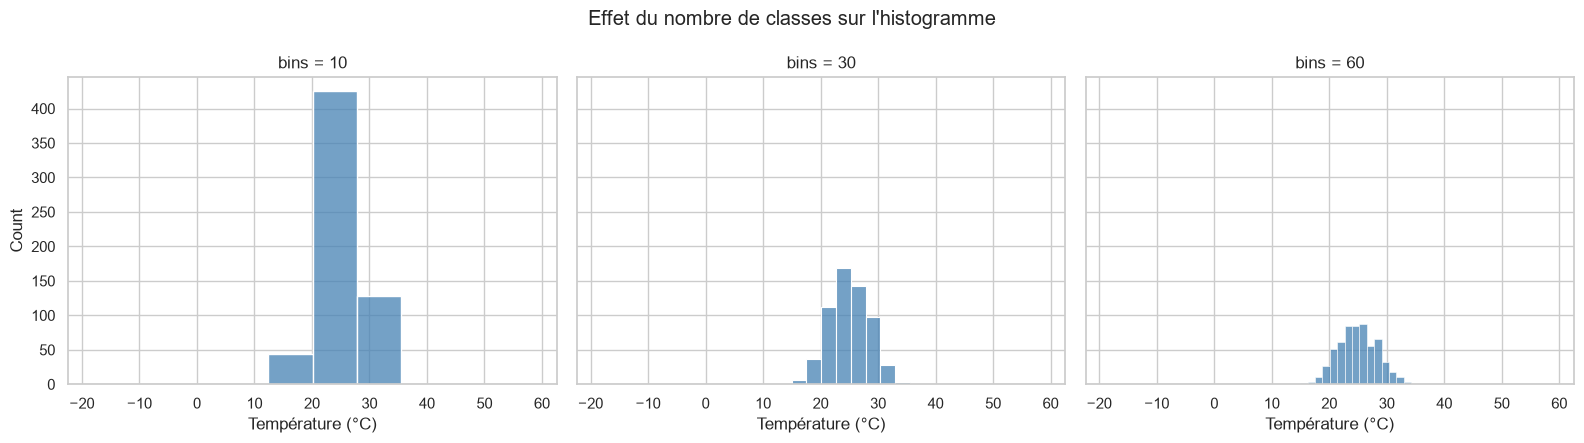

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, nb_bins in zip(axes, [10, 30, 60]):
    sns.histplot(data=df, x="temperature", bins=nb_bins, color="steelblue", ax=ax)
    ax.set_title(f"bins = {nb_bins}")
    ax.set_xlabel("Température (°C)")

fig.suptitle("Effet du nombre de classes sur l'histogramme")
plt.tight_layout()
plt.show()

Plus le nombre de classes augmente, plus le détail de la distribution apparaît (on distingue mieux les valeurs extrêmes isolées), mais la lecture générale de la tendance devient aussi plus bruitée. À l'inverse, un faible nombre de classes lisse la distribution au risque de masquer certains détails.

6) Distribution des températures par bâtiment

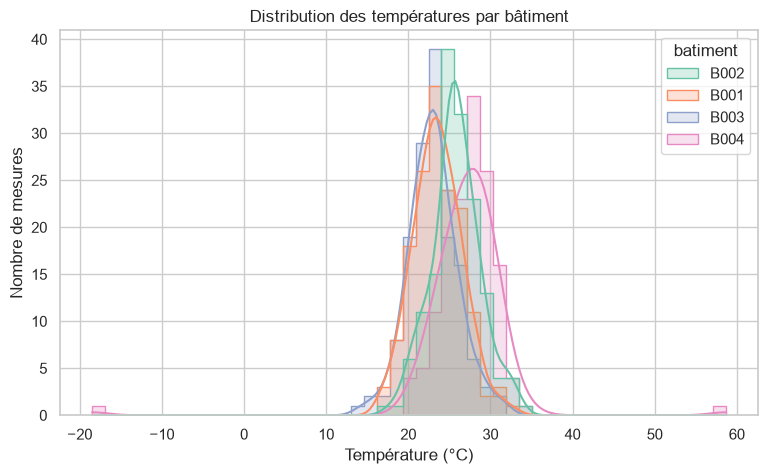

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="temperature", hue="batiment", kde=True, element="step", palette="Set2")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")
plt.show()

Le bâtiment B004 se distingue nettement des trois autres : sa distribution est plus étalée et c'est lui qui porte les valeurs extrêmes (-18,5°C et 58,7°C), alors que B001, B002 et B003 restent regroupés dans une plage plus resserrée autour de 24-26°C.